In [1]:
import os
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Tentukan Root Path Repositori
NOTEBOOK_DIR = Path(os.getcwd())
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocess import preprocess_audio, TARGET_SR
from src.embeddings import AudioRepresentationExtractor

MANIFEST_DIR = REPO_ROOT / "data" / "manifests"
RESULTS_PROC_DIR = REPO_ROOT / "results" / "processed"
RESULTS_FIG_DIR = REPO_ROOT / "results" / "figures"
PAPER_TABLE_DIR = REPO_ROOT / "paper" / "tables"
PAPER_FIG_DIR = REPO_ROOT / "paper" / "figures"
FEATURES_DIR = REPO_ROOT / "results" / "features"

for d in [RESULTS_PROC_DIR, RESULTS_FIG_DIR, PAPER_TABLE_DIR, PAPER_FIG_DIR, FEATURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SPLIT_CSV = MANIFEST_DIR / "dataset_split.csv"
if not SPLIT_CSV.exists():
    raise FileNotFoundError("Berkas dataset_split.csv belum ditemukan!")

df_split = pd.read_csv(SPLIT_CSV)
df_gal = df_split[df_split["split_role"] == "gallery"].reset_index(drop=True)
df_qry = df_split[df_split["split_role"] == "query_clean"].reset_index(drop=True)

print(f"[+] Root Repositori: {REPO_ROOT}")
print(f"[+] Total Galeri Termuat     : {len(df_gal):,} rekaman ({df_gal['species_key'].nunique()} spesies)")
print(f"[+] Total Kueri Bersih Termuat: {len(df_qry):,} rekaman ({df_qry['species_key'].nunique()} spesies)")

[+] Root Repositori: d:\FILE AND TASK\TA
[+] Total Galeri Termuat     : 3,653 rekaman (20 spesies)
[+] Total Kueri Bersih Termuat: 200 rekaman (20 spesies)


In [2]:
print("[*] Melakukan prapemrosesan audio sinyal kueri (200 berkas)...")
start_t = time.time()
qry_audio_signals = [preprocess_audio(str(REPO_ROOT / p)) for p in df_qry["file_path"]]
print(f"[+] Selesai prapemrosesan kueri dalam {time.time() - start_t:.1f} detik.")

print("[*] Melakukan prapemrosesan audio sinyal galeri (3.653 berkas)...")
start_t = time.time()
gal_audio_signals = [preprocess_audio(str(REPO_ROOT / p)) for p in df_gal["file_path"]]
print(f"[+] Selesai prapemrosesan galeri dalam {time.time() - start_t:.1f} detik.")

[*] Melakukan prapemrosesan audio sinyal kueri (200 berkas)...


c:\Users\Fabio\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[+] Selesai prapemrosesan kueri dalam 15.2 detik.
[*] Melakukan prapemrosesan audio sinyal galeri (3.653 berkas)...
[+] Selesai prapemrosesan galeri dalam 244.9 detik.


In [3]:
representations = ["R0", "R1", "R2", "R3"]
embeddings_cache = {}

for rep in representations:
    cache_path = FEATURES_DIR / f"clean_embeddings_{rep}.npz"
    
    if cache_path.exists():
        print(f"[*] Memuat cache representasi {rep} dari: {cache_path.name}...")
        data = np.load(cache_path)
        gal_feats = data["gal_feats"]
        qry_feats = data["qry_feats"]
    else:
        print(f"[*] Mengekstrak fitur untuk representasi {rep}...")
        start_rep = time.time()
        extractor = AudioRepresentationExtractor(rep)
        
        gal_feats = np.array([extractor.extract(y) for y in gal_audio_signals], dtype=np.float32)
        qry_feats = np.array([extractor.extract(y) for y in qry_audio_signals], dtype=np.float32)
        
        np.savez_compressed(cache_path, gal_feats=gal_feats, qry_feats=qry_feats)
        print(f"[+] Ekstraksi {rep} selesai dalam {time.time() - start_rep:.1f} detik (Disimpan ke cache).")
        
    embeddings_cache[rep] = {"gal": gal_feats, "qry": qry_feats}
    print(f"    - Galeri Dimensi : {gal_feats.shape} | L2-Norm: {np.linalg.norm(gal_feats[0]):.4f}")
    print(f"    - Kueri Dimensi  : {qry_feats.shape} | L2-Norm: {np.linalg.norm(qry_feats[0]):.4f}")

[*] Memuat cache representasi R0 dari: clean_embeddings_R0.npz...
    - Galeri Dimensi : (3653, 40) | L2-Norm: 1.0000
    - Kueri Dimensi  : (200, 40) | L2-Norm: 1.0000
[*] Memuat cache representasi R1 dari: clean_embeddings_R1.npz...
    - Galeri Dimensi : (3653, 2048) | L2-Norm: 1.0000
    - Kueri Dimensi  : (200, 2048) | L2-Norm: 1.0000
[*] Memuat cache representasi R2 dari: clean_embeddings_R2.npz...
    - Galeri Dimensi : (3653, 1024) | L2-Norm: 1.0000
    - Kueri Dimensi  : (200, 1024) | L2-Norm: 1.0000
[*] Memuat cache representasi R3 dari: clean_embeddings_R3.npz...
    - Galeri Dimensi : (3653, 40) | L2-Norm: 1.0000
    - Kueri Dimensi  : (200, 40) | L2-Norm: 1.0000


In [4]:
rep_names = {
    "R0": "R0: MFCC Baseline (40-d)",
    "R1": "R1: PANNs CNN14 (2048-d)",
    "R2": "R2: BirdNET Backbone (1024-d)",
    "R3": "R3: Random Control (40-d)"
}

summary_table = []
per_query_table = []

gal_species = df_gal["species_key"].values
gal_authors = df_gal["author"].values

for rep in representations:
    gal_feats = embeddings_cache[rep]["gal"]
    qry_feats = embeddings_cache[rep]["qry"]
    
    # Matriks Kesamaan Kosinus (200 x 3653)
    sim_matrix = cosine_similarity(qry_feats, gal_feats)
    
    top1_hits = 0
    aps_at_10 = []
    reciprocal_ranks = []
    recalls_at_10 = []
    precisions_at_10 = []
    
    for i, q_row in df_qry.iterrows():
        target_sp = q_row["species_key"]
        scores = sim_matrix[i]
        
        # Urutkan peringkat dari skor terbesar ke terkecil
        ranked_idx = np.argsort(scores)[::-1]
        ranked_sp = gal_species[ranked_idx]
        
        is_relevant = (ranked_sp == target_sp)
        total_relevant = int(np.sum(is_relevant))
        
        # Top-1 Match
        if is_relevant[0]:
            top1_hits += 1
            
        # MRR (Mean Reciprocal Rank)
        first_idx = np.where(is_relevant)[0]
        rr = 1.0 / (first_idx[0] + 1) if len(first_idx) > 0 else 0.0
        reciprocal_ranks.append(rr)
        
        # Precision@10 & Recall@10
        top10_rel = is_relevant[:10]
        hits_10 = int(np.sum(top10_rel))
        prec10 = hits_10 / 10.0
        rec10 = hits_10 / max(1, total_relevant)
        precisions_at_10.append(prec10)
        recalls_at_10.append(rec10)
        
        # Average Precision @ 10 (AP@10)
        hits = 0
        prec_sum = 0.0
        for k in range(10):
            if is_relevant[k]:
                hits += 1
                prec_sum += hits / (k + 1)
        ap10 = prec_sum / min(10, max(1, total_relevant))
        aps_at_10.append(ap10)
        
        # Catatan per-query sesuai Audit H5.2 (Wajib memuat kolom author)
        per_query_table.append({
            "query_id": q_row["recording_id"],
            "species_key": target_sp,
            "author": q_row["author"],
            "top1_match": ranked_sp[0],
            "max_similarity": float(scores[ranked_idx[0]]),
            "total_relevant_in_gallery": total_relevant,
            "reciprocal_rank": float(rr),
            "P@10": float(prec10),
            "R@10": float(rec10),
            "AP@10": float(ap10),
            "representation": rep
        })
        
    summary_table.append({
        "representation": rep,
        "name": rep_names[rep],
        "Top1_Accuracy": (top1_hits / len(df_qry)) * 100.0,
        "mAP@10": float(np.mean(aps_at_10)),
        "MRR": float(np.mean(reciprocal_ranks)),
        "Recall@10": float(np.mean(recalls_at_10)),
        "Precision@10": float(np.mean(precisions_at_10))
    })

df_summary = pd.DataFrame(summary_table)
df_per_query = pd.DataFrame(per_query_table)

# Simpan Tabel Kanonik
df_summary.to_csv(RESULTS_PROC_DIR / "clean_retrieval_table.csv", index=False)
df_summary.to_csv(PAPER_TABLE_DIR / "clean_retrieval_table.csv", index=False)

df_per_query.to_csv(RESULTS_PROC_DIR / "per_query_clean_retrieval.csv", index=False)
df_per_query.to_csv(PAPER_TABLE_DIR / "per_query_clean_retrieval.csv", index=False)

print("\n" + "=" * 80)
print("HASIL EVALUASI E1 CLEAN RETRIEVAL BENCHMARK (BIRDCLEF+ 2026):")
print("=" * 80)
display(df_summary)


HASIL EVALUASI E1 CLEAN RETRIEVAL BENCHMARK (BIRDCLEF+ 2026):


,representation,name,Top1_Accuracy,mAP@10,MRR,Recall@10,Precision@10
0,R0,R0: MFCC Baseline (40-d),27.5,0.131949,0.422441,0.012261,0.2175
1,R1,R1: PANNs CNN14 (2048-d),60.0,0.415234,0.700513,0.029087,0.5025
2,R2,R2: BirdNET Backbone (1024-d),95.0,0.912619,0.965780,0.052792,0.9280
3,R3,R3: Random Control (40-d),6.5,0.019010,0.177897,0.002828,0.0530


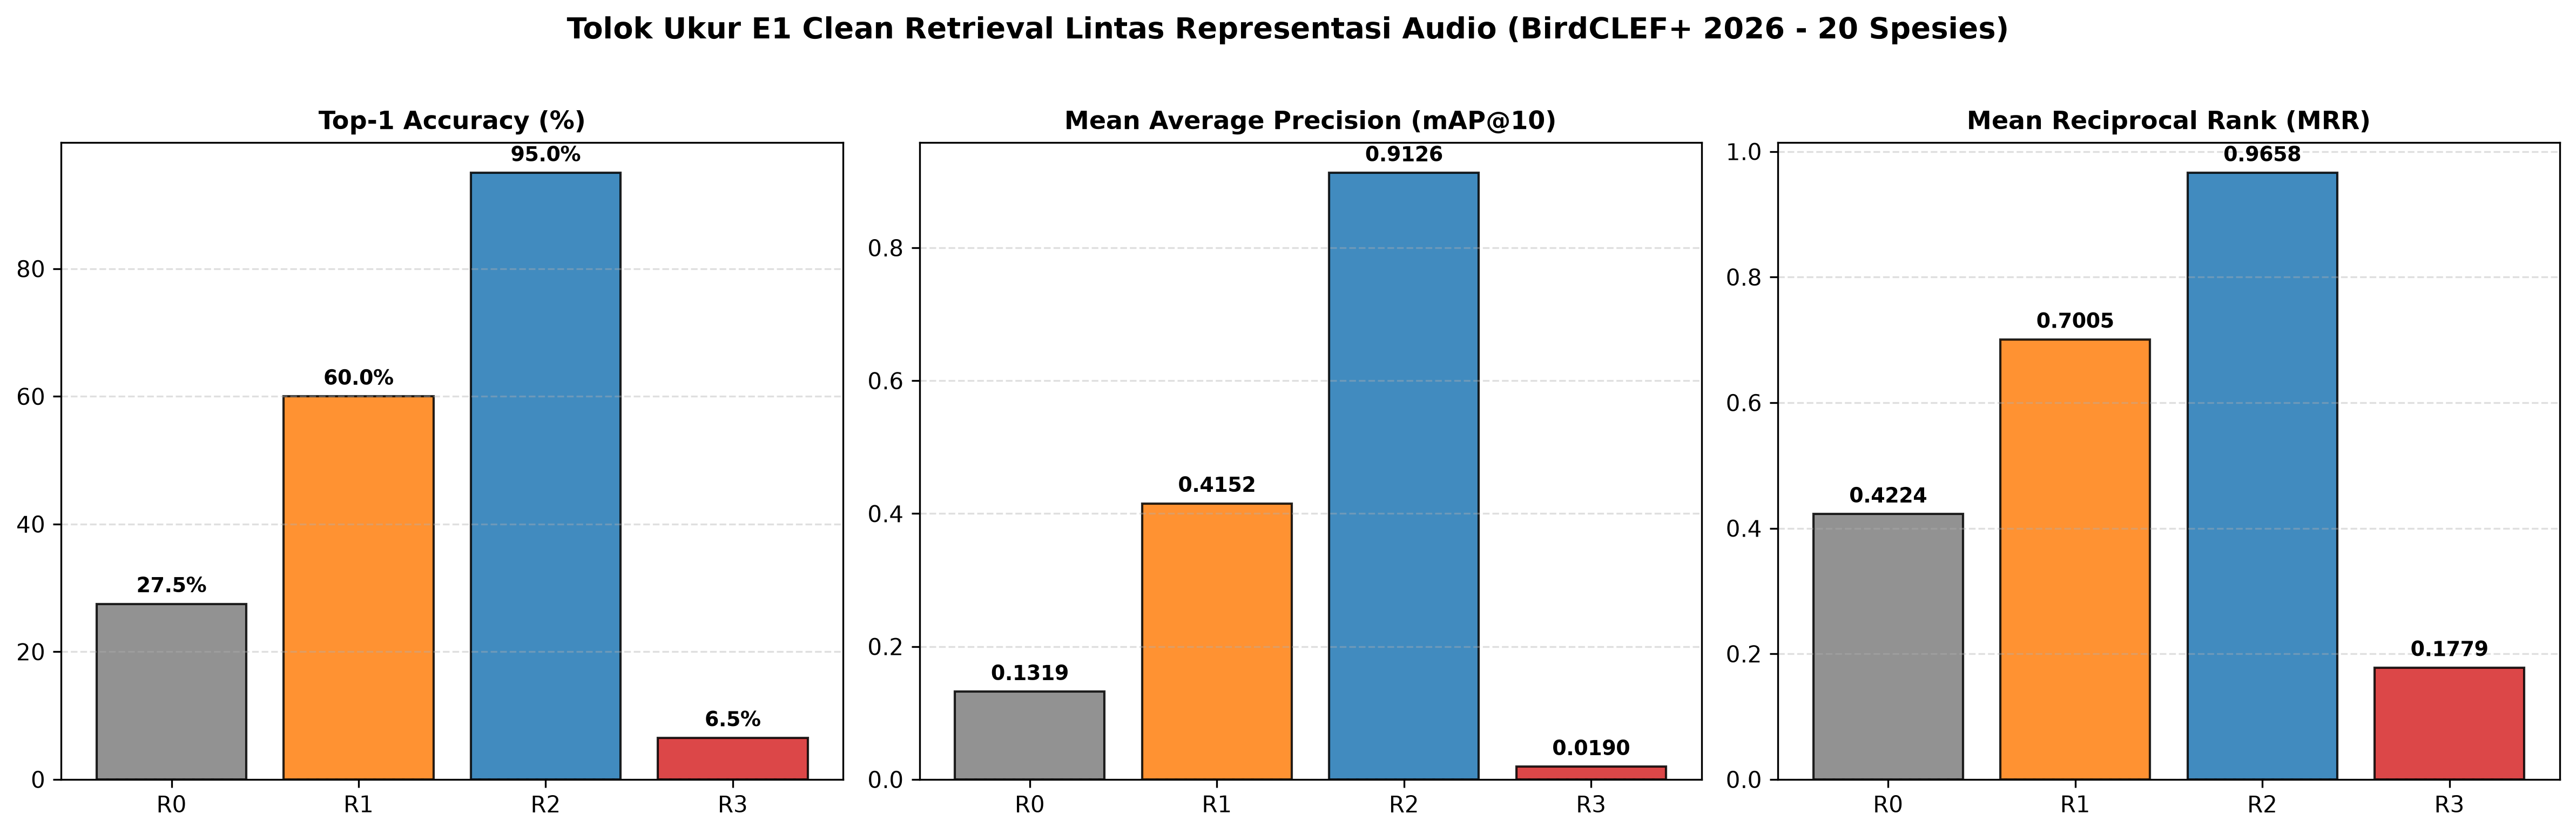

[+] Gambar benchmark disimpan ke:
    - d:\FILE AND TASK\TA\results\figures\clean_retrieval_benchmark.png
    - d:\FILE AND TASK\TA\paper\figures\clean_retrieval_benchmark.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=300)

metrics = [
    ("Top1_Accuracy", "Top-1 Accuracy (%)", axes[0]), 
    ("mAP@10", "Mean Average Precision (mAP@10)", axes[1]), 
    ("MRR", "Mean Reciprocal Rank (MRR)", axes[2])
]

bar_colors = ["#7f7f7f", "#ff7f0e", "#1f77b4", "#d62728"]

for col, title, ax in metrics:
    bars = ax.bar(df_summary["representation"], df_summary[col], color=bar_colors, edgecolor="black", alpha=0.85)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")
    for bar in bars:
        h = bar.get_height()
        label_text = f"{h:.1f}%" if "%" in title else f"{h:.4f}"
        ax.annotate(label_text, xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Tolok Ukur E1 Clean Retrieval Lintas Representasi Audio (BirdCLEF+ 2026 - 20 Spesies)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

fig_e1_1 = RESULTS_FIG_DIR / "clean_retrieval_benchmark.png"
fig_e1_2 = PAPER_FIG_DIR / "clean_retrieval_benchmark.png"

plt.savefig(fig_e1_1, bbox_inches="tight", dpi=300)
plt.savefig(fig_e1_2, bbox_inches="tight", dpi=300)
plt.show()

print(f"[+] Gambar benchmark disimpan ke:\n    - {fig_e1_1}\n    - {fig_e1_2}")